# 04. Clasificación de nodos con Graph Neural Networks

Este notebook implementa modelos GNN para clasificar transacciones ilícitas en el dataset Elliptic.

Se divide en tres partes

3A. GNN supervisada-only
    → Esto ya lo hiciste.
    → Solo usa nodos licit/illicit.
    → Excluye unknown del grafo.
    → Resultado: GCN y GraphSAGE tienen alto recall, pero baja precision y menor PR-AUC que XGBoost.

3B. GNN con unknown como contexto estructural
    → Esto es lo que haremos ahora.
    → Usa el grafo completo.
    → Mantiene unknown como nodos de contexto.
    → La pérdida solo se calcula sobre licit/illicit de train.

3C. Ajuste de umbral con validation
    → Se aplica después de 3B.
    → No cambia PR-AUC ni ROC-AUC.
    → Sirve para mejorar precision, recall o F1 según el umbral elegido.

Los modelos iniciales serán:

1. GCN.
2. GraphSAGE.

### Nivel 3A: GNN supervisada-only
Se mantiene:

- `licit` se codifica como 0.
- `illicit` se codifica como 1.
- `unknown` no se usa como etiqueta supervisada.
- El split se realiza de forma temporal.
- Los resultados se comparan contra el baseline clásico principal: XGBoost.
  
Resultado: no supera a XGBoost, pero alcanza alto recall.

In [1]:
# Imports y rutas
import sys
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from aml_gnn.utils.paths import INTERIM_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, EXPERIMENTS_DIR
from aml_gnn.graph.build_pyg import build_pyg_data
from aml_gnn.models.gcn import GCNNodeClassifier
from aml_gnn.models.graphsage import GraphSAGENodeClassifier
from aml_gnn.training.train_gnn_node import (
    compute_class_weights,
    train_one_epoch,
    predict_scores,
)
from aml_gnn.evaluation.metrics import evaluate_binary_classifier

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("PROJECT_ROOT:", PROJECT_ROOT)

/home/lucho/miniconda3/envs/gnn_tesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.12.0+cpu
CUDA disponible: False
PROJECT_ROOT: /home/lucho/aml-gnn-tesis


In [2]:
# Definiendo dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado:", device)

Dispositivo usado: cpu


In [3]:
# Cargando datos intermedios
nodes_path = INTERIM_DIR / "nodes_with_graph_features.parquet"
edges_path = INTERIM_DIR / "edges_interim.parquet"

nodes_df = pd.read_parquet(nodes_path)
edges_df = pd.read_parquet(edges_path)

print("Nodes:", nodes_df.shape)
print("Edges:", edges_df.shape)

nodes_df.head()

Nodes: (203769, 171)
Edges: (234355, 2)


,txId,timestep,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_159,f_160,f_161,f_162,f_163,f_164,label,in_degree,out_degree,total_degree
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,1,1,2
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,1,1,2
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,1,2,3
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,licit,160,1,161
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,2,8,10


In [4]:
# Filtrando nodos etiquetados y creando split
# Para esta primera GNN se considera que solo entran al objeto PyG los nodos licit/illicit.
supervised_df = nodes_df[
    nodes_df["label"].isin(["licit", "illicit"])
].copy()

supervised_df["target"] = supervised_df["label"].map({
    "licit": 0,
    "illicit": 1
}).astype(int)

unique_timesteps = np.array(sorted(supervised_df["timestep"].unique()))

n_timesteps = len(unique_timesteps)
train_end_idx = int(n_timesteps * 0.70)
val_end_idx = int(n_timesteps * 0.85)

train_timesteps = unique_timesteps[:train_end_idx]
val_timesteps = unique_timesteps[train_end_idx:val_end_idx]
test_timesteps = unique_timesteps[val_end_idx:]

def assign_split(timestep):
    if timestep in train_timesteps:
        return "train"
    if timestep in val_timesteps:
        return "val"
    return "test"

supervised_df["split"] = supervised_df["timestep"].apply(assign_split)

split_pivot = (
    supervised_df
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
    .pivot(index="split", columns="label", values="count")
    .fillna(0)
    .astype(int)
)

split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot["illicit_percentage"] = (
    split_pivot["illicit"] / split_pivot["total"] * 100
).round(2)

split_pivot

label,illicit,licit,total,illicit_percentage
split,,,,
test,408,8433,8841,4.61
train,3462,26432,29894,11.58
val,675,7154,7829,8.62


In [5]:
# Filtrando aristas al subconjunto supervisado
supervised_node_ids = set(supervised_df["txId"])

supervised_edges_df = edges_df[
    edges_df["txId1"].isin(supervised_node_ids) &
    edges_df["txId2"].isin(supervised_node_ids)
].copy()

print("Aristas originales:", edges_df.shape)
print("Aristas supervisadas:", supervised_edges_df.shape)

Aristas originales: (234355, 2)
Aristas supervisadas: (36624, 2)


In [6]:
# Seleccion de features
feature_cols = [
    col for col in supervised_df.columns
    if col.startswith("f_")
]

graph_feature_cols = [
    "in_degree",
    "out_degree",
    "total_degree"
]

feature_cols = feature_cols + graph_feature_cols

print("Número de features:", len(feature_cols))
feature_cols[:10], feature_cols[-10:]

Número de features: 168


(['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9'],
 ['f_158',
  'f_159',
  'f_160',
  'f_161',
  'f_162',
  'f_163',
  'f_164',
  'in_degree',
  'out_degree',
  'total_degree'])

In [8]:
# Escalado de features

scaler = StandardScaler()

train_mask_np = supervised_df["split"] == "train"

# 1. Ajustar el scaler únicamente con train
scaler.fit(
    supervised_df.loc[train_mask_np, feature_cols]
)

# 2. Transformar todas las particiones con el scaler ajustado en train
scaled_features = scaler.transform(
    supervised_df[feature_cols]
).astype(np.float32)

# 3. Crear DataFrame nuevo con las features escaladas
scaled_feature_df = pd.DataFrame(
    scaled_features,
    columns=feature_cols,
    index=supervised_df.index
)

# 4. Separar columnas que no serán escaladas
non_feature_cols = [
    col for col in supervised_df.columns
    if col not in feature_cols
]

# 5. Reconstruir el DataFrame final
supervised_df_scaled = pd.concat(
    [
        supervised_df[non_feature_cols].copy(),
        scaled_feature_df
    ],
    axis=1
)

# 6. Verificación rápida
print("Shape original:", supervised_df.shape)
print("Shape escalado:", supervised_df_scaled.shape)
print("Features escaladas:", len(feature_cols))

supervised_df_scaled[feature_cols].head()

Shape original: (46564, 173)
Shape escalado: (46564, 173)
Features escaladas: 168


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_158,f_159,f_160,f_161,f_162,f_163,f_164,in_degree,out_degree,total_degree
3,0.440554,3.700982,-0.401777,7.739264,-0.051133,6.133802,20.361403,-0.128868,-0.055751,-0.035166,...,0.185424,1.807527,0.024222,-0.074518,0.601232,-0.122236,-0.120173,25.297176,-0.028227,22.156071
9,0.137516,1.181631,0.143298,2.670922,-0.051133,2.873969,1.413334,-0.128868,-0.109939,-0.048655,...,0.185424,1.023479,-0.013345,-0.074518,0.298915,-0.122236,-0.120173,9.150718,-0.028227,8.005326
10,-0.119987,-0.207543,-0.946853,-0.171139,-0.041600,-0.172106,-0.082566,-0.074019,-0.109099,-0.088655,...,0.185424,0.043420,-0.060305,-0.074518,-0.078981,-0.122236,-0.120173,-0.281372,0.247260,-0.120844
11,-0.126305,-0.207543,-0.946853,-0.171139,-0.041600,-0.172106,-0.082566,-0.081667,-0.115768,-0.088655,...,-1.099307,0.043420,-0.060305,-0.074518,-0.078981,-0.122236,-0.120173,-0.121506,-0.028227,-0.120844
16,-0.164075,-0.207543,-0.946853,-0.076404,-0.041600,-0.118666,0.416067,-0.128855,-0.156277,-0.087233,...,0.185424,0.043420,-0.050913,-0.051236,-0.041191,-1.874823,-1.875233,-0.121506,-0.028227,-0.120844


In [9]:
# Construyendo objeto PyG
data, node_to_idx, idx_to_node = build_pyg_data(
    nodes_df=supervised_df_scaled,
    edges_df=supervised_edges_df,
    feature_cols=feature_cols,
    target_col="target",
    split_col="split",
    node_col="txId",
)

data

/home/lucho/aml-gnn-tesis/src/aml_gnn/graph/build_pyg.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor(


Data(x=[46564, 168], edge_index=[2, 36624], y=[46564], train_mask=[46564], val_mask=[46564], test_mask=[46564])

In [10]:
# Validando dimensiones
print("x:", data.x.shape)
print("edge_index:", data.edge_index.shape)
print("y:", data.y.shape)

print("Train:", int(data.train_mask.sum()))
print("Val:", int(data.val_mask.sum()))
print("Test:", int(data.test_mask.sum()))

print("Clases train:", torch.bincount(data.y[data.train_mask]))
print("Clases val:", torch.bincount(data.y[data.val_mask]))
print("Clases test:", torch.bincount(data.y[data.test_mask]))

x: torch.Size([46564, 168])
edge_index: torch.Size([2, 36624])
y: torch.Size([46564])
Train: 29894
Val: 7829
Test: 8841
Clases train: tensor([26432,  3462])
Clases val: tensor([7154,  675])
Clases test: tensor([8433,  408])


In [11]:
# Guardando graph_data.pt
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

graph_data_path = PROCESSED_DIR / "graph_data_supervised.pt"
scaler_path = MODELS_DIR / "gnn_feature_scaler.pkl"

torch.save(
    {
        "data": data,
        "feature_cols": feature_cols,
        "node_to_idx": node_to_idx,
        "idx_to_node": idx_to_node,
        "split_strategy": "temporal_supervised_only",
    },
    graph_data_path,
)

joblib.dump(scaler, scaler_path)

print("Guardado:", graph_data_path)
print("Guardado:", scaler_path)

Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/graph_data_supervised.pt
Guardado: /home/lucho/aml-gnn-tesis/models/gnn_feature_scaler.pkl


## Entrenando GCN

In [12]:
# Configurando GCN
torch.manual_seed(42)

in_channels = data.x.shape[1]
hidden_channels = 64
out_channels = 2

gcn_model = GCNNodeClassifier(
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    dropout=0.5,
).to(device)

class_weights = compute_class_weights(data.y, data.train_mask).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    gcn_model.parameters(),
    lr=0.001,
    weight_decay=5e-4,
)

print(gcn_model)
print("Class weights:", class_weights)

GCNNodeClassifier(
  (conv1): GCNConv(168, 64)
  (conv2): GCNConv(64, 2)
)
Class weights: tensor([0.5655, 4.3174])


In [13]:
# Entrenando GCN
history_gcn = []

best_val_pr_auc = -1
best_gcn_state = None

for epoch in range(1, 51):
    loss = train_one_epoch(
        model=gcn_model,
        data=data,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_scores = predict_scores(gcn_model, data, device)[data.val_mask.cpu()]
    val_metrics = evaluate_binary_classifier(
        data.y[data.val_mask].cpu().numpy(),
        val_scores.numpy(),
    )

    row = {
        "epoch": epoch,
        "loss": loss,
        "val_pr_auc": val_metrics["pr_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history_gcn.append(row)

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_gcn_state = {
            key: value.cpu().clone()
            for key, value in gcn_model.state_dict().items()
        }

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
            f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

Epoch 001 | Loss: 0.8710 | Val PR-AUC: 0.0820 | Val ROC-AUC: 0.5290 | Val Recall: 0.3289 | Val F1: 0.1120
Epoch 005 | Loss: 0.6274 | Val PR-AUC: 0.1793 | Val ROC-AUC: 0.7667 | Val Recall: 0.9067 | Val F1: 0.2471
Epoch 010 | Loss: 0.5049 | Val PR-AUC: 0.2752 | Val ROC-AUC: 0.8372 | Val Recall: 0.9156 | Val F1: 0.2549
Epoch 015 | Loss: 0.4517 | Val PR-AUC: 0.3402 | Val ROC-AUC: 0.8573 | Val Recall: 0.9007 | Val F1: 0.2750
Epoch 020 | Loss: 0.4155 | Val PR-AUC: 0.4043 | Val ROC-AUC: 0.8669 | Val Recall: 0.8756 | Val F1: 0.2993
Epoch 025 | Loss: 0.3964 | Val PR-AUC: 0.4627 | Val ROC-AUC: 0.8717 | Val Recall: 0.8622 | Val F1: 0.3209
Epoch 030 | Loss: 0.3799 | Val PR-AUC: 0.5092 | Val ROC-AUC: 0.8749 | Val Recall: 0.8563 | Val F1: 0.3329
Epoch 035 | Loss: 0.3708 | Val PR-AUC: 0.5396 | Val ROC-AUC: 0.8779 | Val Recall: 0.8563 | Val F1: 0.3329
Epoch 040 | Loss: 0.3575 | Val PR-AUC: 0.5572 | Val ROC-AUC: 0.8805 | Val Recall: 0.8607 | Val F1: 0.3296
Epoch 045 | Loss: 0.3405 | Val PR-AUC: 0.5693 

In [14]:
# Evaluando GCN en test
gcn_model.load_state_dict(best_gcn_state)
gcn_model = gcn_model.to(device)

gcn_scores_all = predict_scores(gcn_model, data, device)

gcn_val_scores = gcn_scores_all[data.val_mask.cpu()]
gcn_test_scores = gcn_scores_all[data.test_mask.cpu()]

gcn_val_metrics = evaluate_binary_classifier(
    data.y[data.val_mask].cpu().numpy(),
    gcn_val_scores.numpy(),
)

gcn_test_metrics = evaluate_binary_classifier(
    data.y[data.test_mask].cpu().numpy(),
    gcn_test_scores.numpy(),
)

gcn_test_metrics

{'accuracy': 0.6303585567243525,
 'precision': 0.09072696050372066,
 'recall': 0.7769607843137255,
 'f1': 0.16248077908764735,
 'pr_auc': 0.25301622543529845,
 'roc_auc': 0.7996627976460358,
 'confusion_matrix': [[5256, 3177], [91, 317]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.62      0.76      8433\n           1       0.09      0.78      0.16       408\n\n    accuracy                           0.63      8841\n   macro avg       0.54      0.70      0.46      8841\nweighted avg       0.94      0.63      0.74      8841\n',
 'recall_at_50': np.float64(0.051470588235294115),
 'recall_at_100': np.float64(0.10049019607843138),
 'recall_at_500': np.float64(0.39705882352941174),
 'recall_at_1000': np.float64(0.4730392156862745)}

In [15]:
# Reporte GCN
print(gcn_test_metrics["classification_report"])
print("Matriz de confusión:", gcn_test_metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0       0.98      0.62      0.76      8433
           1       0.09      0.78      0.16       408

    accuracy                           0.63      8841
   macro avg       0.54      0.70      0.46      8841
weighted avg       0.94      0.63      0.74      8841

Matriz de confusión: [[5256, 3177], [91, 317]]


## Entrenando GraphSAGE

In [16]:
# Configurando GraphSAGE
torch.manual_seed(42)

sage_model = GraphSAGENodeClassifier(
    in_channels=in_channels,
    hidden_channels=64,
    out_channels=2,
    dropout=0.5,
).to(device)

class_weights = compute_class_weights(data.y, data.train_mask).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    sage_model.parameters(),
    lr=0.001,
    weight_decay=5e-4,
)

print(sage_model)

GraphSAGENodeClassifier(
  (conv1): SAGEConv(168, 64, aggr=mean)
  (conv2): SAGEConv(64, 2, aggr=mean)
)


In [17]:
# Entrenando GraphSAGE
history_sage = []

best_val_pr_auc_sage = -1
best_sage_state = None

for epoch in range(1, 51):
    loss = train_one_epoch(
        model=sage_model,
        data=data,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_scores = predict_scores(sage_model, data, device)[data.val_mask.cpu()]
    val_metrics = evaluate_binary_classifier(
        data.y[data.val_mask].cpu().numpy(),
        val_scores.numpy(),
    )

    row = {
        "epoch": epoch,
        "loss": loss,
        "val_pr_auc": val_metrics["pr_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history_sage.append(row)

    if val_metrics["pr_auc"] > best_val_pr_auc_sage:
        best_val_pr_auc_sage = val_metrics["pr_auc"]
        best_sage_state = {
            key: value.cpu().clone()
            for key, value in sage_model.state_dict().items()
        }

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
            f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

Epoch 001 | Loss: 0.9810 | Val PR-AUC: 0.0681 | Val ROC-AUC: 0.4183 | Val Recall: 0.9467 | Val F1: 0.1627
Epoch 005 | Loss: 0.6608 | Val PR-AUC: 0.1906 | Val ROC-AUC: 0.7423 | Val Recall: 0.9304 | Val F1: 0.1850
Epoch 010 | Loss: 0.5120 | Val PR-AUC: 0.2598 | Val ROC-AUC: 0.8212 | Val Recall: 0.9422 | Val F1: 0.2314
Epoch 015 | Loss: 0.4496 | Val PR-AUC: 0.2918 | Val ROC-AUC: 0.8450 | Val Recall: 0.9407 | Val F1: 0.2439
Epoch 020 | Loss: 0.4056 | Val PR-AUC: 0.3250 | Val ROC-AUC: 0.8605 | Val Recall: 0.9378 | Val F1: 0.2582
Epoch 025 | Loss: 0.3782 | Val PR-AUC: 0.3762 | Val ROC-AUC: 0.8748 | Val Recall: 0.9274 | Val F1: 0.2744
Epoch 030 | Loss: 0.3563 | Val PR-AUC: 0.4398 | Val ROC-AUC: 0.8872 | Val Recall: 0.9230 | Val F1: 0.2902
Epoch 035 | Loss: 0.3370 | Val PR-AUC: 0.5006 | Val ROC-AUC: 0.8969 | Val Recall: 0.9200 | Val F1: 0.3083
Epoch 040 | Loss: 0.3178 | Val PR-AUC: 0.5357 | Val ROC-AUC: 0.9021 | Val Recall: 0.9215 | Val F1: 0.3234
Epoch 045 | Loss: 0.3020 | Val PR-AUC: 0.5539 

In [18]:
# Evaluando GraphSAGE en test
sage_model.load_state_dict(best_sage_state)
sage_model = sage_model.to(device)

sage_scores_all = predict_scores(sage_model, data, device)

sage_val_scores = sage_scores_all[data.val_mask.cpu()]
sage_test_scores = sage_scores_all[data.test_mask.cpu()]

sage_val_metrics = evaluate_binary_classifier(
    data.y[data.val_mask].cpu().numpy(),
    sage_val_scores.numpy(),
)

sage_test_metrics = evaluate_binary_classifier(
    data.y[data.test_mask].cpu().numpy(),
    sage_test_scores.numpy(),
)

sage_test_metrics

{'accuracy': 0.6178034159031783,
 'precision': 0.08975421154377244,
 'recall': 0.7965686274509803,
 'f1': 0.16133035492678083,
 'pr_auc': 0.195461769533762,
 'roc_auc': 0.7906404112694527,
 'confusion_matrix': [[5137, 3296], [83, 325]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.61      0.75      8433\n           1       0.09      0.80      0.16       408\n\n    accuracy                           0.62      8841\n   macro avg       0.54      0.70      0.46      8841\nweighted avg       0.94      0.62      0.73      8841\n',
 'recall_at_50': np.float64(0.041666666666666664),
 'recall_at_100': np.float64(0.06372549019607843),
 'recall_at_500': np.float64(0.3602941176470588),
 'recall_at_1000': np.float64(0.4730392156862745)}

In [19]:
# Reporte GraphSAGE
print(sage_test_metrics["classification_report"])
print("Matriz de confusión:", sage_test_metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0       0.98      0.61      0.75      8433
           1       0.09      0.80      0.16       408

    accuracy                           0.62      8841
   macro avg       0.54      0.70      0.46      8841
weighted avg       0.94      0.62      0.73      8841

Matriz de confusión: [[5137, 3296], [83, 325]]


# Comparando contra baseline clásico

In [20]:
# Cargando baseline clásico
baseline_metrics_path = REPORTS_DIR / "metrics" / "baseline_metrics.json"

with open(baseline_metrics_path, "r", encoding="utf-8") as file:
    baseline_metrics = json.load(file)

xgb_test_metrics = baseline_metrics["xgboost"]["test"]
rf_test_metrics = baseline_metrics["random_forest"]["test"]
logreg_test_metrics = baseline_metrics["logistic_regression"]["test"]

In [21]:
# Creando tabla comparativa
def compact_metrics(model_name, metrics_dict, split="test"):
    return {
        "model": model_name,
        "split": split,
        "accuracy": metrics_dict["accuracy"],
        "precision": metrics_dict["precision"],
        "recall": metrics_dict["recall"],
        "f1": metrics_dict["f1"],
        "pr_auc": metrics_dict["pr_auc"],
        "roc_auc": metrics_dict["roc_auc"],
        "recall_at_50": metrics_dict["recall_at_50"],
        "recall_at_100": metrics_dict["recall_at_100"],
        "recall_at_500": metrics_dict["recall_at_500"],
        "recall_at_1000": metrics_dict["recall_at_1000"],
    }


comparison_rows = [
    compact_metrics("Logistic Regression", logreg_test_metrics),
    compact_metrics("Random Forest", rf_test_metrics),
    compact_metrics("XGBoost", xgb_test_metrics),
    compact_metrics("GCN", gcn_test_metrics),
    compact_metrics("GraphSAGE", sage_test_metrics),
]

gnn_comparison_df = pd.DataFrame(comparison_rows)

gnn_comparison_df.sort_values("pr_auc", ascending=False)

,model,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
2,XGBoost,test,0.956905,0.536585,0.485294,0.509653,0.561439,0.873378,0.122549,0.245098,0.504902,0.558824
1,Random Forest,test,0.974098,0.958974,0.458333,0.620232,0.547510,0.851448,0.122549,0.245098,0.490196,0.529412
3,GCN,test,0.630359,0.090727,0.776961,0.162481,0.253016,0.799663,0.051471,0.100490,0.397059,0.473039
0,Logistic Regression,test,0.727746,0.123540,0.803922,0.214169,0.199037,0.855272,0.007353,0.051471,0.375000,0.517157
4,GraphSAGE,test,0.617803,0.089754,0.796569,0.161330,0.195462,0.790640,0.041667,0.063725,0.360294,0.473039


In [22]:
# Guardando resultados
metrics_dir = REPORTS_DIR / "metrics"
tables_dir = REPORTS_DIR / "tables"
figures_dir = REPORTS_DIR / "figures"
experiment_dir = EXPERIMENTS_DIR / "02_gnn_nodos"

metrics_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
experiment_dir.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

gnn_metrics = {
    "gcn": {
        "validation": gcn_val_metrics,
        "test": gcn_test_metrics,
    },
    "graphsage": {
        "validation": sage_val_metrics,
        "test": sage_test_metrics,
    },
}

gnn_metrics_path = metrics_dir / "gnn_node_metrics.json"
gnn_comparison_path = tables_dir / "gnn_vs_baseline_comparison.csv"

with open(gnn_metrics_path, "w", encoding="utf-8") as file:
    json.dump(gnn_metrics, file, indent=4, ensure_ascii=False)

gnn_comparison_df.to_csv(gnn_comparison_path, index=False)

torch.save(gcn_model.state_dict(), MODELS_DIR / "gcn_model.pt")
torch.save(sage_model.state_dict(), MODELS_DIR / "graphsage_model.pt")

pd.DataFrame(history_gcn).to_csv(experiment_dir / "gcn_training_history.csv", index=False)
pd.DataFrame(history_sage).to_csv(experiment_dir / "graphsage_training_history.csv", index=False)

print("Guardado:", gnn_metrics_path)
print("Guardado:", gnn_comparison_path)
print("Modelos guardados en:", MODELS_DIR)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/gnn_node_metrics.json
Guardado: /home/lucho/aml-gnn-tesis/reports/tables/gnn_vs_baseline_comparison.csv
Modelos guardados en: /home/lucho/aml-gnn-tesis/models


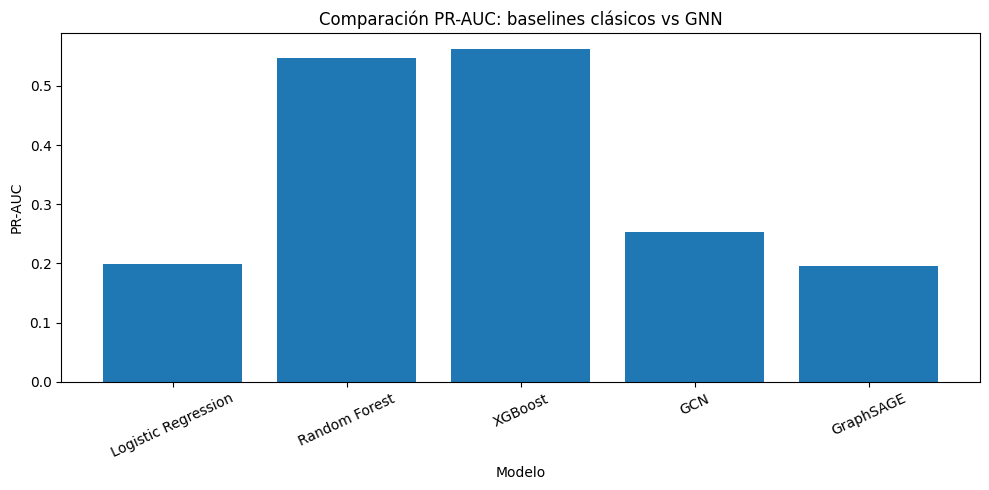

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/gnn_vs_baseline_pr_auc.png


In [23]:
# Gráfico PR-AUC
test_comparison = gnn_comparison_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(test_comparison["model"], test_comparison["pr_auc"])
plt.title("Comparación PR-AUC: baselines clásicos vs GNN")
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.xticks(rotation=25)
plt.tight_layout()

fig_path = figures_dir / "gnn_vs_baseline_pr_auc.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Guardado:", fig_path)

### 3B. GNN con unknown como contexto estructural

En esta variante se conserva el grafo completo del dataset Elliptic. Los nodos `unknown` se mantienen dentro del grafo para aportar contexto relacional, pero no participan en la función de pérdida supervisada.

La lógica será:

- `licit` se codifica como 0.
- `illicit` se codifica como 1.
- `unknown` se codifica como -1.
- Los masks `train`, `val` y `test` solo incluyen nodos `licit` e `illicit`.
- Los nodos `unknown` permanecen en el grafo, pero no son usados para calcular la pérdida.

In [24]:
# Cargando nuevamente los datos completos

nodes_path = INTERIM_DIR / "nodes_with_graph_features.parquet"
edges_path = INTERIM_DIR / "edges_interim.parquet"

full_nodes_df = pd.read_parquet(nodes_path)
full_edges_df = pd.read_parquet(edges_path)

print("Full nodes:", full_nodes_df.shape)
print("Full edges:", full_edges_df.shape)

full_nodes_df["label"].value_counts()

Full nodes: (203769, 171)
Full edges: (234355, 2)


label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

In [25]:
# Creando target:
# licit   -> 0
# illicit -> 1
# unknown -> -1

full_nodes_df = full_nodes_df.copy()

full_nodes_df["target"] = full_nodes_df["label"].map({
    "licit": 0,
    "illicit": 1
}).fillna(-1).astype(int)

# Creando split temporal solo para nodos etiquetados
labeled_mask = full_nodes_df["label"].isin(["licit", "illicit"])

labeled_df = full_nodes_df[labeled_mask].copy()

unique_timesteps = np.array(sorted(labeled_df["timestep"].unique()))

n_timesteps = len(unique_timesteps)
train_end_idx = int(n_timesteps * 0.70)
val_end_idx = int(n_timesteps * 0.85)

train_timesteps = unique_timesteps[:train_end_idx]
val_timesteps = unique_timesteps[train_end_idx:val_end_idx]
test_timesteps = unique_timesteps[val_end_idx:]

def assign_split_full(row):
    if row["label"] not in ["licit", "illicit"]:
        return "unlabeled"
    if row["timestep"] in train_timesteps:
        return "train"
    if row["timestep"] in val_timesteps:
        return "val"
    return "test"

full_nodes_df["split"] = full_nodes_df.apply(assign_split_full, axis=1)

split_full_summary = (
    full_nodes_df
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
)

split_full_summary

,split,label,count
0,test,illicit,408
1,test,licit,8433
2,train,illicit,3462
3,train,licit,26432
4,unlabeled,unknown,157205
5,val,illicit,675
6,val,licit,7154


In [26]:
# Verificando split
split_full_pivot = (
    full_nodes_df[full_nodes_df["label"].isin(["licit", "illicit"])]
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
    .pivot(index="split", columns="label", values="count")
    .fillna(0)
    .astype(int)
)

split_full_pivot["total"] = split_full_pivot.sum(axis=1)
split_full_pivot["illicit_percentage"] = (
    split_full_pivot["illicit"] / split_full_pivot["total"] * 100
).round(2)

split_full_pivot

label,illicit,licit,total,illicit_percentage
split,,,,
test,408,8433,8841,4.61
train,3462,26432,29894,11.58
val,675,7154,7829,8.62


In [27]:
# Seleccion de features
feature_cols_full = [
    col for col in full_nodes_df.columns
    if col.startswith("f_")
]

graph_feature_cols = [
    "in_degree",
    "out_degree",
    "total_degree"
]

feature_cols_full = feature_cols_full + graph_feature_cols

print("Número de features:", len(feature_cols_full))
print("Primeras:", feature_cols_full[:10])
print("Últimas:", feature_cols_full[-10:])

Número de features: 168
Primeras: ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9']
Últimas: ['f_158', 'f_159', 'f_160', 'f_161', 'f_162', 'f_163', 'f_164', 'in_degree', 'out_degree', 'total_degree']


In [28]:
# Escalado evitando data leakage:
# El scaler se ajusta solo con nodos etiquetados de train.

scaler_full = StandardScaler()

train_labeled_mask = full_nodes_df["split"] == "train"

scaler_full.fit(
    full_nodes_df.loc[train_labeled_mask, feature_cols_full]
)

scaled_features_full = scaler_full.transform(
    full_nodes_df[feature_cols_full]
).astype(np.float32)

scaled_feature_full_df = pd.DataFrame(
    scaled_features_full,
    columns=feature_cols_full,
    index=full_nodes_df.index
)

non_feature_cols_full = [
    col for col in full_nodes_df.columns
    if col not in feature_cols_full
]

full_nodes_df_scaled = pd.concat(
    [
        full_nodes_df[non_feature_cols_full].copy(),
        scaled_feature_full_df
    ],
    axis=1
)

print("Shape original:", full_nodes_df.shape)
print("Shape escalado:", full_nodes_df_scaled.shape)

full_nodes_df_scaled[feature_cols_full].head()

Shape original: (203769, 173)
Shape escalado: (203769, 173)


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_158,f_159,f_160,f_161,f_162,f_163,f_164,in_degree,out_degree,total_degree
0,-0.162567,-0.207543,-0.946853,-0.171139,-0.041600,-0.172106,-0.082566,-0.125564,-0.154047,-0.088655,...,1.470154,0.043420,-0.060305,-0.074518,-0.078981,-0.122236,-0.120173,-0.121506,-0.028227,-0.120844
1,-0.162594,-0.207543,-0.946853,-0.171139,-0.041600,-0.172106,-0.082566,-0.125597,-0.154075,-0.088655,...,-1.099307,0.043420,-0.060305,-0.074518,-0.078981,-0.122236,-0.120173,-0.121506,-0.028227,-0.120844
2,-0.163716,-0.207543,-0.946853,-0.171139,-0.041600,-0.172106,-0.082566,-0.126956,-0.155260,-0.088655,...,-1.099307,-0.152592,-0.069696,-0.074518,-0.154560,-0.122236,-0.120173,-0.121506,0.247260,0.019263
3,0.440554,3.700982,-0.401777,7.739264,-0.051133,6.133802,20.361403,-0.128868,-0.055751,-0.035166,...,0.185424,1.807527,0.024222,-0.074518,0.601232,-0.122236,-0.120173,25.297176,-0.028227,22.156071
4,1.970279,-0.019180,-0.946853,0.634111,0.139516,0.736373,-0.082566,-0.128607,0.240881,0.476352,...,0.541342,0.043420,0.118141,0.154666,1.141623,0.196962,0.199476,0.038359,1.900185,1.000007


In [29]:
# Construyendo objeto PyG con grafo completo
data_full, node_to_idx_full, idx_to_node_full = build_pyg_data(
    nodes_df=full_nodes_df_scaled,
    edges_df=full_edges_df,
    feature_cols=feature_cols_full,
    target_col="target",
    split_col="split",
    node_col="txId",
)

data_full

Data(x=[203769, 168], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

In [30]:
# Validando dimensiones
print("x:", data_full.x.shape)
print("edge_index:", data_full.edge_index.shape)
print("y:", data_full.y.shape)

print("Train:", int(data_full.train_mask.sum()))
print("Val:", int(data_full.val_mask.sum()))
print("Test:", int(data_full.test_mask.sum()))

print("Clases train:", torch.bincount(data_full.y[data_full.train_mask]))
print("Clases val:", torch.bincount(data_full.y[data_full.val_mask]))
print("Clases test:", torch.bincount(data_full.y[data_full.test_mask]))

print("Nodos unknown:", int((data_full.y == -1).sum()))

x: torch.Size([203769, 168])
edge_index: torch.Size([2, 234355])
y: torch.Size([203769])
Train: 29894
Val: 7829
Test: 8841
Clases train: tensor([26432,  3462])
Clases val: tensor([7154,  675])
Clases test: tensor([8433,  408])
Nodos unknown: 157205


In [31]:
# Guardando graph_data completo
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

graph_data_full_path = PROCESSED_DIR / "graph_data_full_context.pt"
scaler_full_path = MODELS_DIR / "gnn_full_context_scaler.pkl"

torch.save(
    {
        "data": data_full,
        "feature_cols": feature_cols_full,
        "node_to_idx": node_to_idx_full,
        "idx_to_node": idx_to_node_full,
        "split_strategy": "temporal_full_graph_unknown_context",
        "unknown_policy": "context_only_no_supervised_loss",
    },
    graph_data_full_path,
)

joblib.dump(scaler_full, scaler_full_path)

print("Guardado:", graph_data_full_path)
print("Guardado:", scaler_full_path)

Guardado: /home/lucho/aml-gnn-tesis/data/processed/elliptic/graph_data_full_context.pt
Guardado: /home/lucho/aml-gnn-tesis/models/gnn_full_context_scaler.pkl


#### Entrenamiento GCN con grafo completo

In [ ]:
# Configurando GCN full-context
torch.manual_seed(42)

in_channels_full = data_full.x.shape[1]

gcn_full_model = GCNNodeClassifier(
    in_channels=in_channels_full,
    hidden_channels=64,
    out_channels=2,
    dropout=0.5,
).to(device)

class_weights_full = compute_class_weights(
    data_full.y,
    data_full.train_mask
).to(device)

criterion_full = torch.nn.CrossEntropyLoss(weight=class_weights_full)

optimizer_gcn_full = torch.optim.Adam(
    gcn_full_model.parameters(),
    lr=0.001,
    weight_decay=5e-4,
)

print(gcn_full_model)
print("Class weights:", class_weights_full)

GCNNodeClassifier(
  (conv1): GCNConv(168, 64)
  (conv2): GCNConv(64, 2)
)
Class weights: tensor([0.5655, 4.3174])


In [33]:
# Entrenando GCN full-context
history_gcn_full = []

best_val_pr_auc_gcn_full = -1
best_gcn_full_state = None

for epoch in range(1, 51):
    loss = train_one_epoch(
        model=gcn_full_model,
        data=data_full,
        optimizer=optimizer_gcn_full,
        criterion=criterion_full,
        device=device,
    )

    gcn_full_scores_all = predict_scores(
        gcn_full_model,
        data_full,
        device
    )

    val_scores = gcn_full_scores_all[data_full.val_mask.cpu()]
    val_metrics = evaluate_binary_classifier(
        data_full.y[data_full.val_mask].cpu().numpy(),
        val_scores.numpy(),
    )

    row = {
        "epoch": epoch,
        "loss": loss,
        "val_pr_auc": val_metrics["pr_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history_gcn_full.append(row)

    if val_metrics["pr_auc"] > best_val_pr_auc_gcn_full:
        best_val_pr_auc_gcn_full = val_metrics["pr_auc"]
        best_gcn_full_state = {
            key: value.cpu().clone()
            for key, value in gcn_full_model.state_dict().items()
        }

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
            f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

Epoch 001 | Loss: 0.9025 | Val PR-AUC: 0.0853 | Val ROC-AUC: 0.5467 | Val Recall: 0.4563 | Val F1: 0.1490
Epoch 005 | Loss: 0.6262 | Val PR-AUC: 0.1423 | Val ROC-AUC: 0.6986 | Val Recall: 0.8370 | Val F1: 0.2195
Epoch 010 | Loss: 0.5605 | Val PR-AUC: 0.1772 | Val ROC-AUC: 0.7370 | Val Recall: 0.8281 | Val F1: 0.2294
Epoch 015 | Loss: 0.4989 | Val PR-AUC: 0.2018 | Val ROC-AUC: 0.7480 | Val Recall: 0.7778 | Val F1: 0.2429
Epoch 020 | Loss: 0.4611 | Val PR-AUC: 0.2255 | Val ROC-AUC: 0.7584 | Val Recall: 0.7422 | Val F1: 0.2591
Epoch 025 | Loss: 0.4445 | Val PR-AUC: 0.2459 | Val ROC-AUC: 0.7712 | Val Recall: 0.7511 | Val F1: 0.2700
Epoch 030 | Loss: 0.4151 | Val PR-AUC: 0.2606 | Val ROC-AUC: 0.7848 | Val Recall: 0.7748 | Val F1: 0.2749
Epoch 035 | Loss: 0.4071 | Val PR-AUC: 0.2755 | Val ROC-AUC: 0.7966 | Val Recall: 0.7926 | Val F1: 0.2816
Epoch 040 | Loss: 0.3892 | Val PR-AUC: 0.2953 | Val ROC-AUC: 0.8052 | Val Recall: 0.7911 | Val F1: 0.2914
Epoch 045 | Loss: 0.3796 | Val PR-AUC: 0.3174 

In [34]:
# Evaluando GCN full_context
gcn_full_model.load_state_dict(best_gcn_full_state)
gcn_full_model = gcn_full_model.to(device)

gcn_full_scores_all = predict_scores(
    gcn_full_model,
    data_full,
    device
)

gcn_full_val_scores = gcn_full_scores_all[data_full.val_mask.cpu()]
gcn_full_test_scores = gcn_full_scores_all[data_full.test_mask.cpu()]

gcn_full_val_metrics = evaluate_binary_classifier(
    data_full.y[data_full.val_mask].cpu().numpy(),
    gcn_full_val_scores.numpy(),
)

gcn_full_test_metrics = evaluate_binary_classifier(
    data_full.y[data_full.test_mask].cpu().numpy(),
    gcn_full_test_scores.numpy(),
)

gcn_full_test_metrics

{'accuracy': 0.7210722768917543,
 'precision': 0.11489520958083832,
 'recall': 0.7524509803921569,
 'f1': 0.19935064935064936,
 'pr_auc': 0.1535156959496316,
 'roc_auc': 0.7979651602132611,
 'confusion_matrix': [[6068, 2365], [101, 307]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.72      0.83      8433\n           1       0.11      0.75      0.20       408\n\n    accuracy                           0.72      8841\n   macro avg       0.55      0.74      0.52      8841\nweighted avg       0.94      0.72      0.80      8841\n',
 'recall_at_50': np.float64(0.012254901960784314),
 'recall_at_100': np.float64(0.041666666666666664),
 'recall_at_500': np.float64(0.23774509803921567),
 'recall_at_1000': np.float64(0.4264705882352941)}

In [35]:
# Reporte GCN full_context
print(gcn_full_test_metrics["classification_report"])
print("Matriz de confusión:", gcn_full_test_metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0       0.98      0.72      0.83      8433
           1       0.11      0.75      0.20       408

    accuracy                           0.72      8841
   macro avg       0.55      0.74      0.52      8841
weighted avg       0.94      0.72      0.80      8841

Matriz de confusión: [[6068, 2365], [101, 307]]


#### Entrenamiento GraphSAGE con grafo completo

In [36]:
# Configurando GraphSAGE full-context
torch.manual_seed(42)

sage_full_model = GraphSAGENodeClassifier(
    in_channels=in_channels_full,
    hidden_channels=64,
    out_channels=2,
    dropout=0.5,
).to(device)

optimizer_sage_full = torch.optim.Adam(
    sage_full_model.parameters(),
    lr=0.001,
    weight_decay=5e-4,
)

criterion_full = torch.nn.CrossEntropyLoss(weight=class_weights_full)

print(sage_full_model)

GraphSAGENodeClassifier(
  (conv1): SAGEConv(168, 64, aggr=mean)
  (conv2): SAGEConv(64, 2, aggr=mean)
)


In [37]:
# Entrenando GraphSAGE full-context
history_sage_full = []

best_val_pr_auc_sage_full = -1
best_sage_full_state = None

for epoch in range(1, 51):
    loss = train_one_epoch(
        model=sage_full_model,
        data=data_full,
        optimizer=optimizer_sage_full,
        criterion=criterion_full,
        device=device,
    )

    sage_full_scores_all = predict_scores(
        sage_full_model,
        data_full,
        device
    )

    val_scores = sage_full_scores_all[data_full.val_mask.cpu()]
    val_metrics = evaluate_binary_classifier(
        data_full.y[data_full.val_mask].cpu().numpy(),
        val_scores.numpy(),
    )

    row = {
        "epoch": epoch,
        "loss": loss,
        "val_pr_auc": val_metrics["pr_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history_sage_full.append(row)

    if val_metrics["pr_auc"] > best_val_pr_auc_sage_full:
        best_val_pr_auc_sage_full = val_metrics["pr_auc"]
        best_sage_full_state = {
            key: value.cpu().clone()
            for key, value in sage_full_model.state_dict().items()
        }

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
            f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

Epoch 001 | Loss: 1.0441 | Val PR-AUC: 0.0779 | Val ROC-AUC: 0.4677 | Val Recall: 0.8059 | Val F1: 0.1402
Epoch 005 | Loss: 0.7188 | Val PR-AUC: 0.2025 | Val ROC-AUC: 0.7117 | Val Recall: 0.8622 | Val F1: 0.1841
Epoch 010 | Loss: 0.5206 | Val PR-AUC: 0.3235 | Val ROC-AUC: 0.7864 | Val Recall: 0.9111 | Val F1: 0.2273
Epoch 015 | Loss: 0.4548 | Val PR-AUC: 0.3412 | Val ROC-AUC: 0.8117 | Val Recall: 0.9200 | Val F1: 0.2475
Epoch 020 | Loss: 0.4072 | Val PR-AUC: 0.3612 | Val ROC-AUC: 0.8288 | Val Recall: 0.9259 | Val F1: 0.2639
Epoch 025 | Loss: 0.3815 | Val PR-AUC: 0.3904 | Val ROC-AUC: 0.8437 | Val Recall: 0.9141 | Val F1: 0.2776
Epoch 030 | Loss: 0.3557 | Val PR-AUC: 0.4241 | Val ROC-AUC: 0.8568 | Val Recall: 0.9126 | Val F1: 0.2959
Epoch 035 | Loss: 0.3381 | Val PR-AUC: 0.4577 | Val ROC-AUC: 0.8684 | Val Recall: 0.9052 | Val F1: 0.3105
Epoch 040 | Loss: 0.3202 | Val PR-AUC: 0.4885 | Val ROC-AUC: 0.8775 | Val Recall: 0.8933 | Val F1: 0.3233
Epoch 045 | Loss: 0.3045 | Val PR-AUC: 0.5141 

In [38]:
# Evaluando GraphSAGE full-context
sage_full_model.load_state_dict(best_sage_full_state)
sage_full_model = sage_full_model.to(device)

sage_full_scores_all = predict_scores(
    sage_full_model,
    data_full,
    device
)

sage_full_val_scores = sage_full_scores_all[data_full.val_mask.cpu()]
sage_full_test_scores = sage_full_scores_all[data_full.test_mask.cpu()]

sage_full_val_metrics = evaluate_binary_classifier(
    data_full.y[data_full.val_mask].cpu().numpy(),
    sage_full_val_scores.numpy(),
)

sage_full_test_metrics = evaluate_binary_classifier(
    data_full.y[data_full.test_mask].cpu().numpy(),
    sage_full_test_scores.numpy(),
)

sage_full_test_metrics

{'accuracy': 0.6672322135505033,
 'precision': 0.0985424588086185,
 'recall': 0.7622549019607843,
 'f1': 0.1745230078563412,
 'pr_auc': 0.2521824648909552,
 'roc_auc': 0.8054294171125109,
 'confusion_matrix': [[5588, 2845], [97, 311]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.66      0.79      8433\n           1       0.10      0.76      0.17       408\n\n    accuracy                           0.67      8841\n   macro avg       0.54      0.71      0.48      8841\nweighted avg       0.94      0.67      0.76      8841\n',
 'recall_at_50': np.float64(0.07352941176470588),
 'recall_at_100': np.float64(0.13970588235294118),
 'recall_at_500': np.float64(0.35049019607843135),
 'recall_at_1000': np.float64(0.4387254901960784)}

In [39]:
# Reporte GraphSAGE full-context
print(sage_full_test_metrics["classification_report"])
print("Matriz de confusión:", sage_full_test_metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0       0.98      0.66      0.79      8433
           1       0.10      0.76      0.17       408

    accuracy                           0.67      8841
   macro avg       0.54      0.71      0.48      8841
weighted avg       0.94      0.67      0.76      8841

Matriz de confusión: [[5588, 2845], [97, 311]]


#### Comparación general

In [40]:
# cargando métricas previas
baseline_metrics_path = REPORTS_DIR / "metrics" / "baseline_metrics.json"
gnn_metrics_path = REPORTS_DIR / "metrics" / "gnn_node_metrics.json"

with open(baseline_metrics_path, "r", encoding="utf-8") as file:
    baseline_metrics = json.load(file)

with open(gnn_metrics_path, "r", encoding="utf-8") as file:
    gnn_3a_metrics = json.load(file)

logreg_test_metrics = baseline_metrics["logistic_regression"]["test"]
rf_test_metrics = baseline_metrics["random_forest"]["test"]
xgb_test_metrics = baseline_metrics["xgboost"]["test"]

gcn_3a_test_metrics = gnn_3a_metrics["gcn"]["test"]
sage_3a_test_metrics = gnn_3a_metrics["graphsage"]["test"]

In [41]:
# Tabla comparativa
def compact_metrics(model_name, metrics_dict, split="test"):
    return {
        "model": model_name,
        "split": split,
        "accuracy": metrics_dict["accuracy"],
        "precision": metrics_dict["precision"],
        "recall": metrics_dict["recall"],
        "f1": metrics_dict["f1"],
        "pr_auc": metrics_dict["pr_auc"],
        "roc_auc": metrics_dict["roc_auc"],
        "recall_at_50": metrics_dict["recall_at_50"],
        "recall_at_100": metrics_dict["recall_at_100"],
        "recall_at_500": metrics_dict["recall_at_500"],
        "recall_at_1000": metrics_dict["recall_at_1000"],
    }


comparison_rows_full = [
    compact_metrics("Logistic Regression", logreg_test_metrics),
    compact_metrics("Random Forest", rf_test_metrics),
    compact_metrics("XGBoost", xgb_test_metrics),
    compact_metrics("GCN 3A supervised-only", gcn_3a_test_metrics),
    compact_metrics("GraphSAGE 3A supervised-only", sage_3a_test_metrics),
    compact_metrics("GCN 3B full-context", gcn_full_test_metrics),
    compact_metrics("GraphSAGE 3B full-context", sage_full_test_metrics),
]

gnn_full_comparison_df = pd.DataFrame(comparison_rows_full)

gnn_full_comparison_df.sort_values("pr_auc", ascending=False)

,model,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
2,XGBoost,test,0.956905,0.536585,0.485294,0.509653,0.561439,0.873378,0.122549,0.245098,0.504902,0.558824
1,Random Forest,test,0.974098,0.958974,0.458333,0.620232,0.547510,0.851448,0.122549,0.245098,0.490196,0.529412
3,GCN 3A supervised-only,test,0.630359,0.090727,0.776961,0.162481,0.253016,0.799663,0.051471,0.100490,0.397059,0.473039
6,GraphSAGE 3B full-context,test,0.667232,0.098542,0.762255,0.174523,0.252182,0.805429,0.073529,0.139706,0.350490,0.438725
0,Logistic Regression,test,0.727746,0.123540,0.803922,0.214169,0.199037,0.855272,0.007353,0.051471,0.375000,0.517157
4,GraphSAGE 3A supervised-only,test,0.617803,0.089754,0.796569,0.161330,0.195462,0.790640,0.041667,0.063725,0.360294,0.473039
5,GCN 3B full-context,test,0.721072,0.114895,0.752451,0.199351,0.153516,0.797965,0.012255,0.041667,0.237745,0.426471


In [42]:
# Guardando resultados 3B
metrics_dir = REPORTS_DIR / "metrics"
tables_dir = REPORTS_DIR / "tables"
figures_dir = REPORTS_DIR / "figures"
experiment_dir = EXPERIMENTS_DIR / "02_gnn_nodos"

metrics_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
experiment_dir.mkdir(parents=True, exist_ok=True)

gnn_full_metrics = {
    "gcn_full_context": {
        "validation": gcn_full_val_metrics,
        "test": gcn_full_test_metrics,
    },
    "graphsage_full_context": {
        "validation": sage_full_val_metrics,
        "test": sage_full_test_metrics,
    },
}

gnn_full_metrics_path = metrics_dir / "gnn_node_metrics_full_context.json"
gnn_full_comparison_path = tables_dir / "gnn_full_context_vs_baseline_comparison.csv"

with open(gnn_full_metrics_path, "w", encoding="utf-8") as file:
    json.dump(gnn_full_metrics, file, indent=4, ensure_ascii=False)

gnn_full_comparison_df.to_csv(gnn_full_comparison_path, index=False)

torch.save(gcn_full_model.state_dict(), MODELS_DIR / "gcn_full_context_model.pt")
torch.save(sage_full_model.state_dict(), MODELS_DIR / "graphsage_full_context_model.pt")

pd.DataFrame(history_gcn_full).to_csv(
    experiment_dir / "gcn_full_context_training_history.csv",
    index=False
)

pd.DataFrame(history_sage_full).to_csv(
    experiment_dir / "graphsage_full_context_training_history.csv",
    index=False
)

print("Guardado:", gnn_full_metrics_path)
print("Guardado:", gnn_full_comparison_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/gnn_node_metrics_full_context.json
Guardado: /home/lucho/aml-gnn-tesis/reports/tables/gnn_full_context_vs_baseline_comparison.csv


### 3C. Ajuste de umbral con validation

En esta sección se ajusta el umbral de decisión usando el conjunto de validación. El objetivo es evaluar si las GNN pueden mejorar su equilibrio entre precision, recall y F1, en lugar de usar de forma fija el umbral 0.5.

El umbral se selecciona usando validation y luego se aplica una sola vez sobre test.

In [43]:
# Función para buscar mejor umbral
from sklearn.metrics import precision_score, recall_score, f1_score


def find_best_threshold_by_f1(y_true, y_score, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)

        rows.append({
            "threshold": float(threshold),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    threshold_df = pd.DataFrame(rows)

    best_row = threshold_df.sort_values(
        by="f1",
        ascending=False
    ).iloc[0]

    return best_row, threshold_df

In [44]:
# Optimizar umbral para GCN y GraphSAGE full-context
y_val_full = data_full.y[data_full.val_mask].cpu().numpy()
y_test_full = data_full.y[data_full.test_mask].cpu().numpy()

best_gcn_threshold, gcn_threshold_df = find_best_threshold_by_f1(
    y_val_full,
    gcn_full_val_scores.numpy()
)

best_sage_threshold, sage_threshold_df = find_best_threshold_by_f1(
    y_val_full,
    sage_full_val_scores.numpy()
)

print("Mejor umbral GCN full-context:")
display(best_gcn_threshold)

print("Mejor umbral GraphSAGE full-context:")
display(best_sage_threshold)

Mejor umbral GCN full-context:


threshold    0.770000
precision    0.345574
recall       0.543704
f1           0.422568
Name: 76, dtype: float64

Mejor umbral GraphSAGE full-context:


threshold    0.860000
precision    0.483721
recall       0.616296
f1           0.542020
Name: 85, dtype: float64

In [ ]:
# Evaluando en test con umbral optimizado
gcn_full_test_metrics_threshold = evaluate_binary_classifier(
    y_test_full,
    gcn_full_test_scores.numpy(),
    threshold=float(best_gcn_threshold["threshold"])
)

sage_full_test_metrics_threshold = evaluate_binary_classifier(
    y_test_full,
    sage_full_test_scores.numpy(),
    threshold=float(best_sage_threshold["threshold"])
)

print("GCN full-context con umbral optimizado:")
print(gcn_full_test_metrics_threshold["classification_report"])
print("Matriz de confusión:", gcn_full_test_metrics_threshold["confusion_matrix"])

print("\nGraphSAGE full-context con umbral optimizado:")
print(sage_full_test_metrics_threshold["classification_report"])
print("Matriz de confusión:", sage_full_test_metrics_threshold["confusion_matrix"])

GCN full-context con umbral optimizado:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      8433
           1       0.17      0.43      0.24       408

    accuracy                           0.88      8841
   macro avg       0.57      0.66      0.59      8841
weighted avg       0.93      0.88      0.90      8841

Matriz de confusión: [[7577, 856], [233, 175]]

GraphSAGE full-context con umbral optimizado:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      8433
           1       0.18      0.43      0.26       408

    accuracy                           0.88      8841
   macro avg       0.58      0.67      0.60      8841
weighted avg       0.93      0.88      0.91      8841

Matriz de confusión: [[7646, 787], [231, 177]]


In [46]:
# Comparación umbral 0.5 vs umbral optimizado
threshold_comparison_rows = [
    compact_metrics("GCN 3B full-context threshold=0.5", gcn_full_test_metrics),
    compact_metrics(
        f"GCN 3B full-context threshold={best_gcn_threshold['threshold']:.2f}",
        gcn_full_test_metrics_threshold
    ),
    compact_metrics("GraphSAGE 3B full-context threshold=0.5", sage_full_test_metrics),
    compact_metrics(
        f"GraphSAGE 3B full-context threshold={best_sage_threshold['threshold']:.2f}",
        sage_full_test_metrics_threshold
    ),
]

threshold_comparison_df = pd.DataFrame(threshold_comparison_rows)

threshold_comparison_df


,model,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
0,GCN 3B full-context threshold=0.5,test,0.721072,0.114895,0.752451,0.199351,0.153516,0.797965,0.012255,0.041667,0.237745,0.426471
1,GCN 3B full-context threshold=0.77,test,0.876824,0.169738,0.428922,0.243224,0.153516,0.797965,0.012255,0.041667,0.237745,0.426471
2,GraphSAGE 3B full-context threshold=0.5,test,0.667232,0.098542,0.762255,0.174523,0.252182,0.805429,0.073529,0.139706,0.350490,0.438725
3,GraphSAGE 3B full-context threshold=0.86,test,0.884855,0.183610,0.433824,0.258017,0.252182,0.805429,0.073529,0.139706,0.350490,0.438725


In [47]:
# Guardar resultados 3C
threshold_results_path = tables_dir / "gnn_threshold_tuning_results.csv"
threshold_metrics_path = metrics_dir / "gnn_threshold_tuning_metrics.json"

threshold_comparison_df.to_csv(threshold_results_path, index=False)

threshold_metrics = {
    "gcn_full_context": {
        "best_threshold_validation": float(best_gcn_threshold["threshold"]),
        "validation_threshold_metrics": best_gcn_threshold.to_dict(),
        "test_metrics_threshold_optimized": gcn_full_test_metrics_threshold,
    },
    "graphsage_full_context": {
        "best_threshold_validation": float(best_sage_threshold["threshold"]),
        "validation_threshold_metrics": best_sage_threshold.to_dict(),
        "test_metrics_threshold_optimized": sage_full_test_metrics_threshold,
    },
}

with open(threshold_metrics_path, "w", encoding="utf-8") as file:
    json.dump(threshold_metrics, file, indent=4, ensure_ascii=False)

print("Guardado:", threshold_results_path)
print("Guardado:", threshold_metrics_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/gnn_threshold_tuning_results.csv
Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/gnn_threshold_tuning_metrics.json
